# Adult Income Dataset - Feature Engineering

## Objective

The objective of this notebook is to create meaningful features, reduce data complexity, handle skewness and outliers, and prepare the dataset for machine learning model development.

## Feature Engineering Goals

- Reduce cardinality
- Improve interpretability
- Reduce skewness
- Handle outliers
- Create business-oriented features
- Improve model readiness

# Feature Engineering Strategy

Based on the EDA findings:

1. Age will be grouped into career stages.
2. Working hours will be converted into work intensity categories.
3. Education levels will be consolidated.
4. Marital categories will be simplified.
5. Occupations will be grouped into business-oriented categories.
6. Household roles will be simplified.
7. Investment-related features will be created.
8. Highly skewed features will be transformed.
9. Extreme outliers will be treated using IQR capping.

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
df = pd.read_csv('/content/adult.csv')

In [183]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [184]:
df.shape

(32561, 15)

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [186]:
df.replace('?',np.nan,inplace = True)

In [187]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [188]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


In [189]:
for col in df.columns:
  df[col] = df[col]

In [190]:
df['workclass'].fillna(df['workclass'].mode()[0],inplace = True)
df['occupation'].fillna(df['occupation'].mode()[0],inplace = True)
df['native.country'].fillna(df['native.country'].mode()[0],inplace = True)
df['income'].fillna(df['income'].mode()[0],inplace = True)
df['hours.per.week'].fillna(df['hours.per.week'].median(),inplace = True)

/tmp/ipykernel_5031/3813615329.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['workclass'].fillna(df['workclass'].mode()[0],inplace = True)
/tmp/ipykernel_5031/3813615329.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [191]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [192]:
df.duplicated().sum()

np.int64(24)

In [193]:
df.drop_duplicates(inplace = True)

In [194]:
df.drop('fnlwgt',axis = 1,inplace = True)

## Feature Removal

### fnlwgt

The fnlwgt feature represents a census weighting factor and provides limited business value for income prediction.

### Decision

The feature was removed to reduce noise and simplify the dataset.

In [195]:
num_cols = df.select_dtypes(
    include = ['int','float']
).columns.tolist()

Binning and grouping

In [196]:
df['age_groups'] = pd.cut(
    df['age'],
    bins = [17,25,35,50,60,100],
    labels=[
        'Young Adult',
        'Early Career',
        'Mid Career',
        'Senior Professional',
        'Retired'
    ]
)

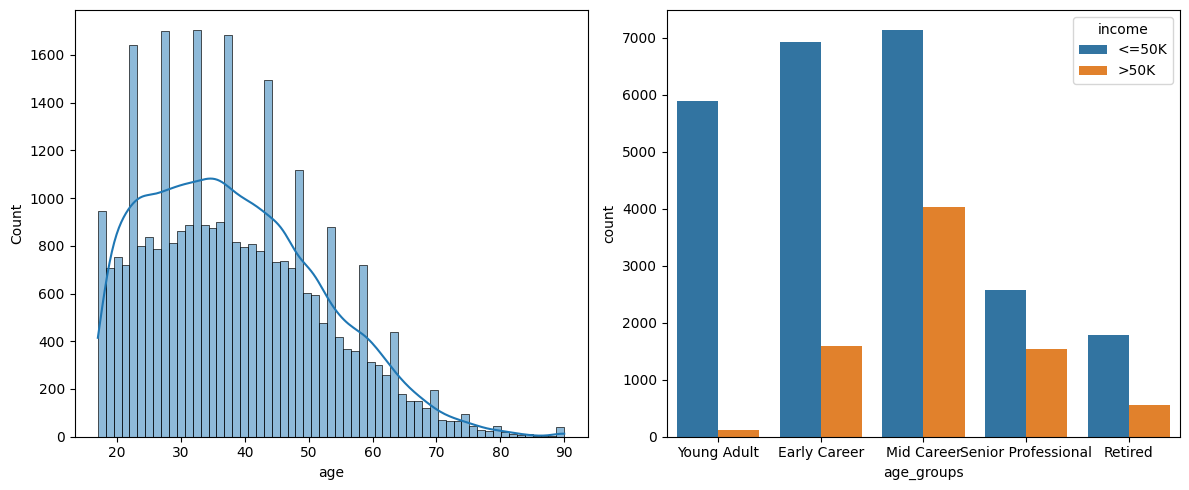

In [197]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=df,x='age',kde = True)
plt.subplot(1,2,2)
sns.countplot(data=df,x='age_groups',hue = 'income')
plt.tight_layout()
plt.show()

## Age Group Feature

### Objective

Reduce the continuous age variable into meaningful career-stage categories.

### Original Feature

- age

### Engineered Feature

- age_group

### Rationale

Individuals at different career stages often exhibit different earning patterns.

### Expected Benefit

Improved interpretability and potentially better target separation.

In [198]:
df['work_intensity'] = pd.cut(
    df['hours.per.week'],
    bins=[0,20,40,60,100],
    labels=[
        'Part Time',
        'Full Time',
        'Overtime',
        'Heavy Overtime'
    ]
)

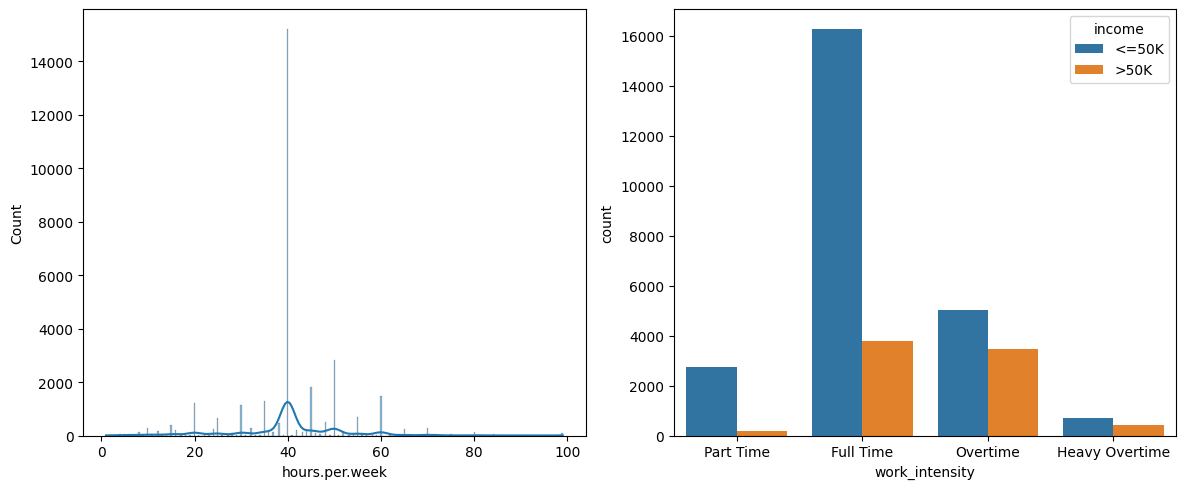

In [199]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=df,x='hours.per.week',kde = True)
plt.subplot(1,2,2)
sns.countplot(data=df,x='work_intensity',hue = 'income')
plt.tight_layout()
plt.show()

## Work Intensity Feature

### Objective

Transform working hours into meaningful workload categories.

### Original Feature

- hours.per.week

### Engineered Feature

- work_intensity

### Rationale

Individuals working overtime may exhibit different income patterns compared to part-time workers.

### Expected Benefit

Improved business interpretation.

In [200]:
education_map = {
    'Preschool': 'School Education',
    '1st-4th': 'School Education',
    '5th-6th': 'School Education',
    '7th-8th': 'School Education',
    '9th': 'School Education',
    '10th': 'School Education',
    '11th': 'School Education',
    '12th': 'School Education',

    'HS-grad': 'High School Graduate',

    'Some-college': 'Undergraduate',
    'Assoc-acdm': 'Undergraduate',
    'Assoc-voc': 'Undergraduate',

    'Bachelors': 'Graduate',

    'Masters': 'Postgraduate',

    'Prof-school': 'Professional Degree',

    'Doctorate': 'Doctorate'
}

In [201]:
df['education_level'] = df['education'].map(education_map)

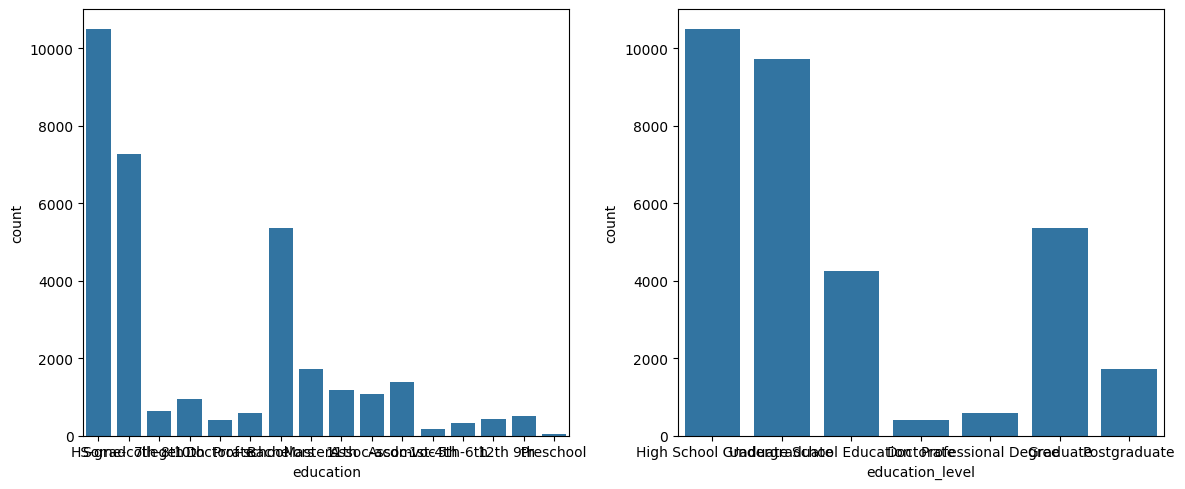

In [202]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=df,x='education')
plt.subplot(1,2,2)
sns.countplot(data=df,x='education_level')
plt.tight_layout()
plt.show()

In [203]:
pd.DataFrame({
    'Original Categories': [df['education'].nunique()],
    'Engineered Categories': [df['education_level'].nunique()]
})

,Original Categories,Engineered Categories
0,16,7


In [204]:
pd.crosstab(
    df['education_level'],
    df['income'],
    normalize='index'
) * 100

income,<=50K,>50K
education_level,,
Doctorate,25.907990,74.092010
Graduate,58.509247,41.490753
High School Graduate,84.048027,15.951973
Postgraduate,44.308943,55.691057
Professional Degree,26.562500,73.437500
School Education,94.256121,5.743879
Undergraduate,79.323811,20.676189


## Education Level Feature

### Objective

Reduce education category cardinality.

### Original Categories

16 categories

### Engineered Categories

5 categories

### Rationale

Grouping educational levels reduces noise and improves interpretability.

### Expected Benefit

Simpler and more meaningful education representation.

In [205]:
marital_map = {
    'Married-civ-spouse': 'Married',
    'Married-AF-spouse': 'Married',
    'Married-spouse-absent': 'Married',

    'Never-married': 'Single',

    'Divorced': 'Previously Married',
    'Separated': 'Previously Married',
    'Widowed': 'Previously Married'
}

df['marital_group'] = df['marital.status'].map(marital_map)

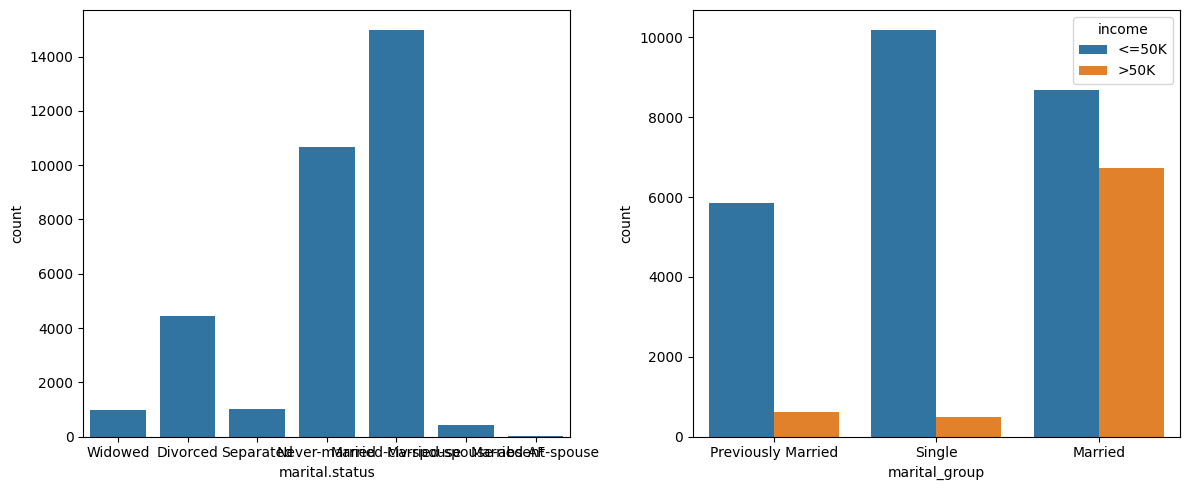

In [206]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=df,x='marital.status')
plt.subplot(1,2,2)
sns.countplot(data=df,x='marital_group',hue = 'income')
plt.tight_layout()
plt.show()

In [207]:
pd.crosstab(
    df['marital_group'],
    df['income'],
    normalize='index'
) * 100

income,<=50K,>50K
marital_group,,
Married,56.303939,43.696061
Previously Married,90.493885,9.506115
Single,95.397019,4.602981


## Marital Group Feature

### Objective

Reduce marital status complexity.

### Original Categories

7 categories

### Engineered Categories

3 categories

### Rationale

Many marital categories share similar behavioral patterns.

### Expected Benefit

Reduced dimensionality.

In [208]:
occupation_map = {
    'Exec-managerial': 'White Collar',
    'Prof-specialty': 'White Collar',
    'Adm-clerical': 'White Collar',
    'Sales': 'White Collar',
    'Tech-support': 'White Collar',

    'Craft-repair': 'Skilled Labor',
    'Machine-op-inspct': 'Skilled Labor',
    'Transport-moving': 'Skilled Labor',
    'Farming-fishing': 'Skilled Labor',

    'Handlers-cleaners': 'Blue Collar',

    'Other-service': 'Service',
    'Priv-house-serv': 'Service',

    'Protective-serv': 'Public Service',

    'Armed-Forces': 'Military'
}

df['occupation_group'] = df['occupation'].map(occupation_map)

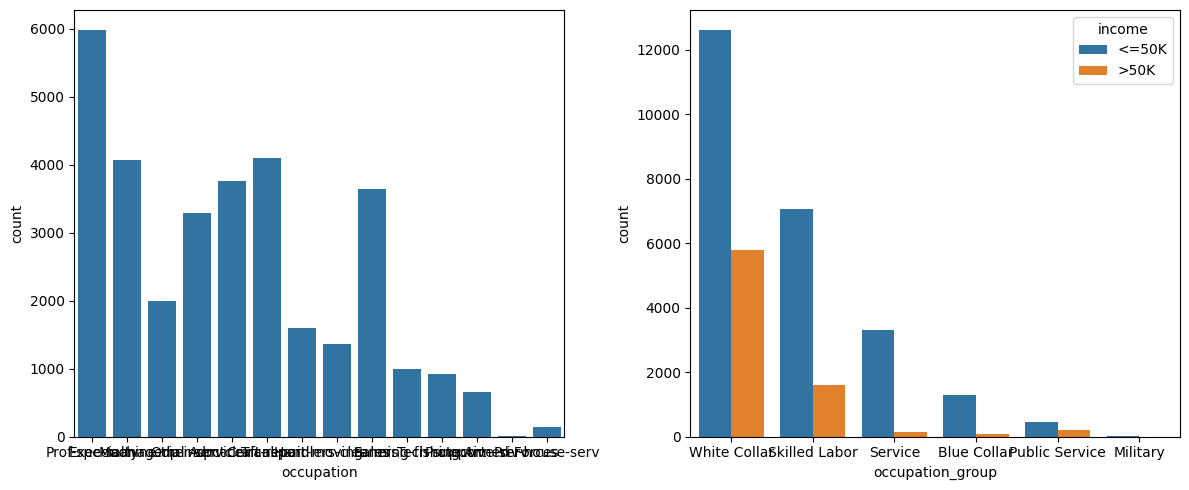

In [209]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=df,x='occupation')
plt.subplot(1,2,2)
sns.countplot(data=df,x='occupation_group',hue='income')
plt.tight_layout()
plt.show()

In [210]:
pd.crosstab(
    df['occupation_group'],
    df['income'],
    normalize='index'
)*100

income,<=50K,>50K
occupation_group,,
Blue Collar,93.718042,6.281958
Military,88.888889,11.111111
Public Service,67.488444,32.511556
Service,95.986038,4.013962
Skilled Labor,81.423471,18.576529
White Collar,68.513785,31.486215


## Occupation Group Feature

### Objective

Group occupations based on business similarity.

### Original Categories

14 categories

### Engineered Categories

5 categories

### Expected Benefit

Reduced cardinality and improved business relevance.

In [211]:
relationship_map = {
    'Husband': 'Spouse',
    'Wife': 'Spouse',

    'Own-child': 'Child',

    'Other-relative': 'Relative',

    'Unmarried': 'Independent Adult',
    'Not-in-family': 'Independent Adult'
}

df['family_role'] = df['relationship'].map(relationship_map)

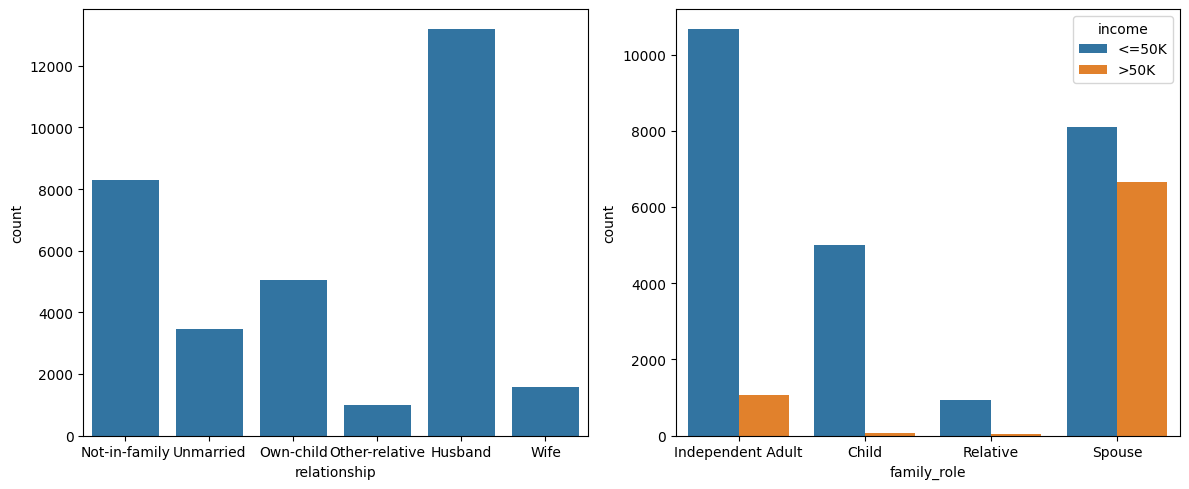

In [212]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=df,x='relationship')
plt.subplot(1,2,2)
sns.countplot(data=df,x='family_role',hue = 'income')
plt.tight_layout()
plt.show()

In [213]:
pd.crosstab(
    df['family_role'],
    df['income'],
    normalize='index'
)*100

income,<=50K,>50K
family_role,,
Child,98.676935,1.323065
Independent Adult,90.849450,9.150550
Relative,96.228338,3.771662
Spouse,54.855981,45.144019


## Family Role Feature

### Objective

Simplify household relationship categories.

### Rationale

Household roles may influence earning behavior.

### Expected Benefit

Improved household structure representation.

In [214]:
df['investment_activity'] = np.where(
    (df['capital.gain'] > 0) |
    (df['capital.loss'] > 0),
    'Yes',
    'No'
)

<Axes: xlabel='investment_activity', ylabel='count'>

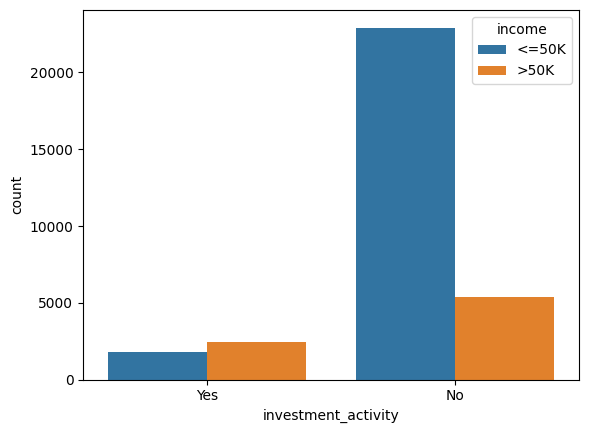

In [215]:
sns.countplot(data=df,x='investment_activity',hue = 'income')

In [216]:
pd.crosstab(
    df['investment_activity'],
    df['income'],
    normalize='index'
)*100

income,<=50K,>50K
investment_activity,,
No,80.961634,19.038366
Yes,42.094068,57.905932


## Investment Activity Feature

### Objective

Create a binary indicator of investment participation.

### Original Features

- capital.gain
- capital.loss

### Engineered Feature

- investment_activity

### Expected Benefit

Captures financial activity in a simpler format.

In [217]:
region_map = {
    'United-States': 'North America',
    'Canada': 'North America',

    'England': 'Europe',
    'Germany': 'Europe',
    'France': 'Europe',
    'Italy': 'Europe',
    'Ireland': 'Europe',
    'Portugal': 'Europe',
    'Greece': 'Europe',
    'Scotland': 'Europe',

    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Iran': 'Asia',
    'Vietnam': 'Asia',
    'Taiwan': 'Asia',
    'Philippines': 'Asia',
    'Hong': 'Asia',
    'Cambodia': 'Asia',
    'Thailand': 'Asia',
    'Laos': 'Asia',

    'Mexico': 'Latin America',
    'Cuba': 'Latin America',
    'Jamaica': 'Latin America',
    'Puerto-Rico': 'Latin America',
    'Dominican-Republic': 'Latin America',
    'Haiti': 'Latin America',
    'Guatemala': 'Latin America',
    'Nicaragua': 'Latin America',
    'El-Salvador': 'Latin America',
    'Honduras': 'Latin America',
    'Columbia': 'Latin America',
    'Ecuador': 'Latin America',
    'Peru': 'Latin America',
    'Trinadad&Tobago': 'Latin America',

    'South': 'Other',
    'Poland': 'Other',
    'Hungary': 'Other',
    'Yugoslavia': 'Other',
    'Holand-Netherlands': 'Other'
}

df['region'] = df['native.country'].map(region_map)

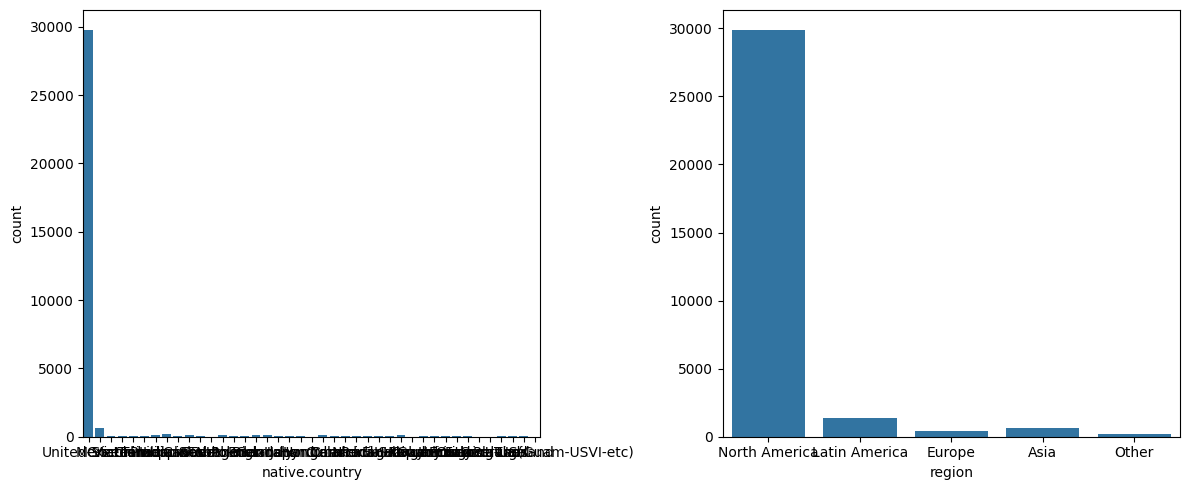

In [218]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=df,x='native.country')
plt.subplot(1,2,2)
sns.countplot(data=df,x='region')
plt.tight_layout()
plt.show()

In [219]:
pd.crosstab(
    df['region'],
    df['income'],
    normalize='index'
)*100

income,<=50K,>50K
region,,
Asia,69.299553,30.700447
Europe,69.605568,30.394432
Latin America,92.043011,7.956989
North America,75.368435,24.631565
Other,78.235294,21.764706


## Region Feature

### Objective

Reduce country-level cardinality by grouping countries into broader geographic regions.

### Original Feature

- native.country

### Engineered Feature

- region

### Rationale

Many countries have very few observations. Grouping countries improves interpretability and reduces category sparsity.

### Expected Benefit

Reduced cardinality and improved model generalization.

Log-Transformation

In [220]:
skewness = {}
for col in num_cols:
  skewness[col] = df[col].skew()

skewness

{'age': np.float64(0.5576631514973126),
 'education.num': np.float64(-0.30950025998998987),
 'capital.gain': np.float64(11.949402833551476),
 'capital.loss': np.float64(4.592702423271815),
 'hours.per.week': np.float64(0.2287588778525044)}

In [221]:
df['capital_gain_log'] = np.log1p(df['capital.gain'])

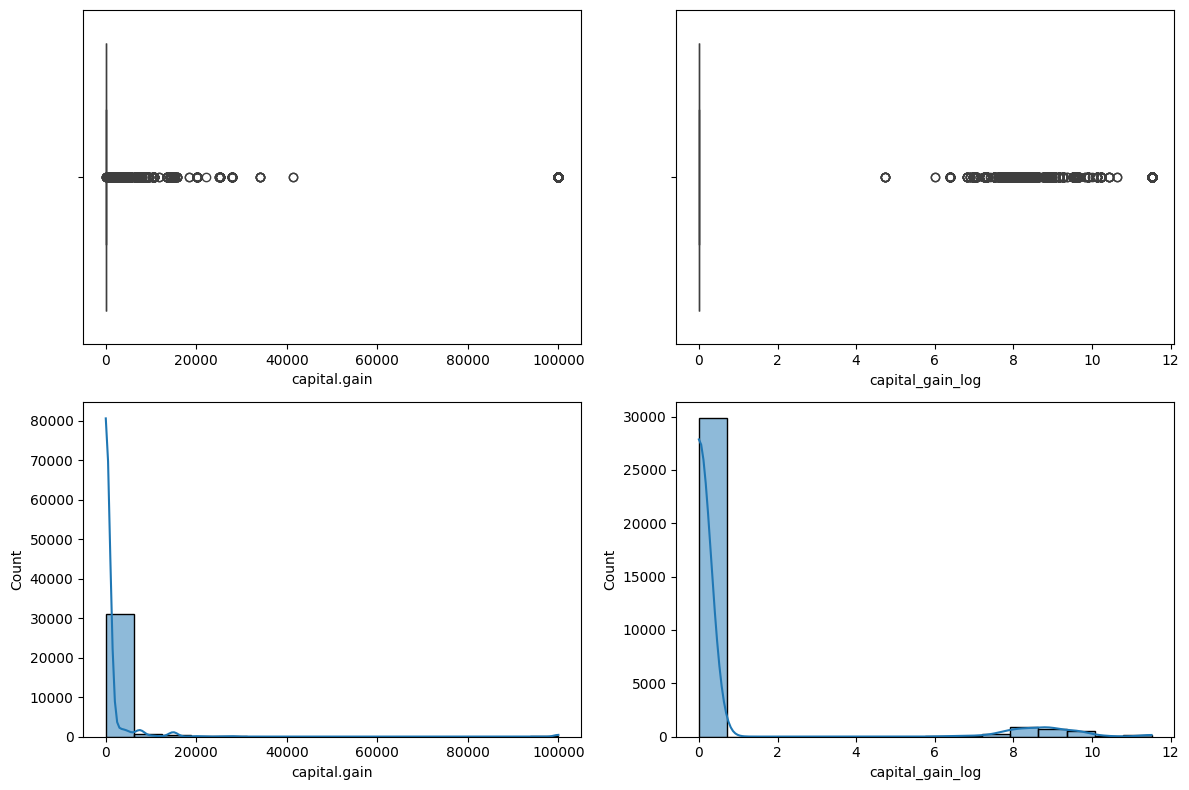

In [222]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.boxplot(data=df, x='capital.gain')

plt.subplot(2,2,2)
sns.boxplot(data=df, x='capital_gain_log')

plt.subplot(2,2,3)
sns.histplot(data=df, x='capital.gain', kde=True)

plt.subplot(2,2,4)
sns.histplot(data=df, x='capital_gain_log', kde=True)

plt.tight_layout()
plt.show()

In [223]:
df['capital_loss_log'] = np.log1p(df['capital.loss'])

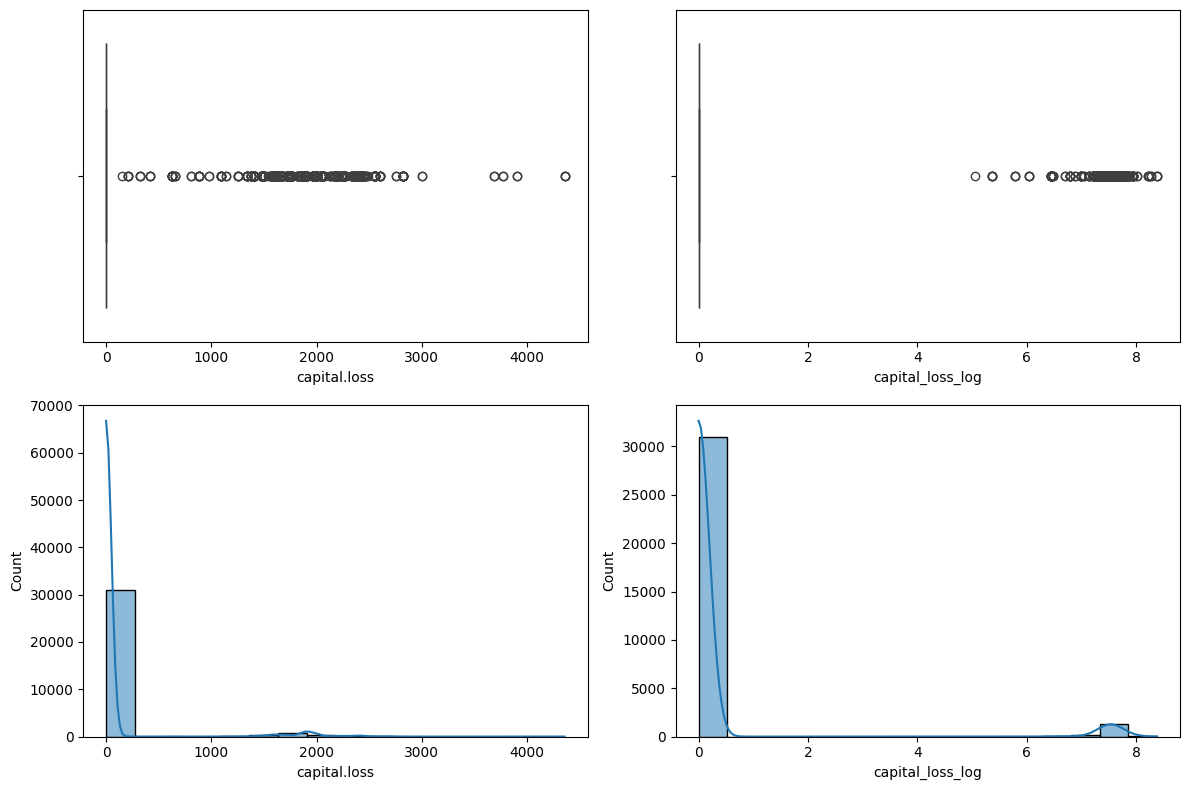

In [224]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.boxplot(data=df, x='capital.loss')

plt.subplot(2,2,2)
sns.boxplot(data=df, x='capital_loss_log')

plt.subplot(2,2,3)
sns.histplot(data=df, x='capital.loss', kde=True)

plt.subplot(2,2,4)
sns.histplot(data=df, x='capital_loss_log', kde=True)

plt.tight_layout()
plt.show()

# Log Transformation

## Objective

Reduce skewness in highly right-skewed numerical variables.

## Features Evaluated

- capital.gain
- capital.loss

## Reason

These variables contain many zero values and a small number of extreme observations.

## Approach

Apply log(1+x) transformation using np.log1p().

IQR

In [225]:
Q1 = df['capital.gain'].quantile(0.25)
Q3 = df['capital.gain'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [226]:
df['capital.gain_iqr'] = np.clip(
    df['capital.gain'],
    lower,
    upper
)

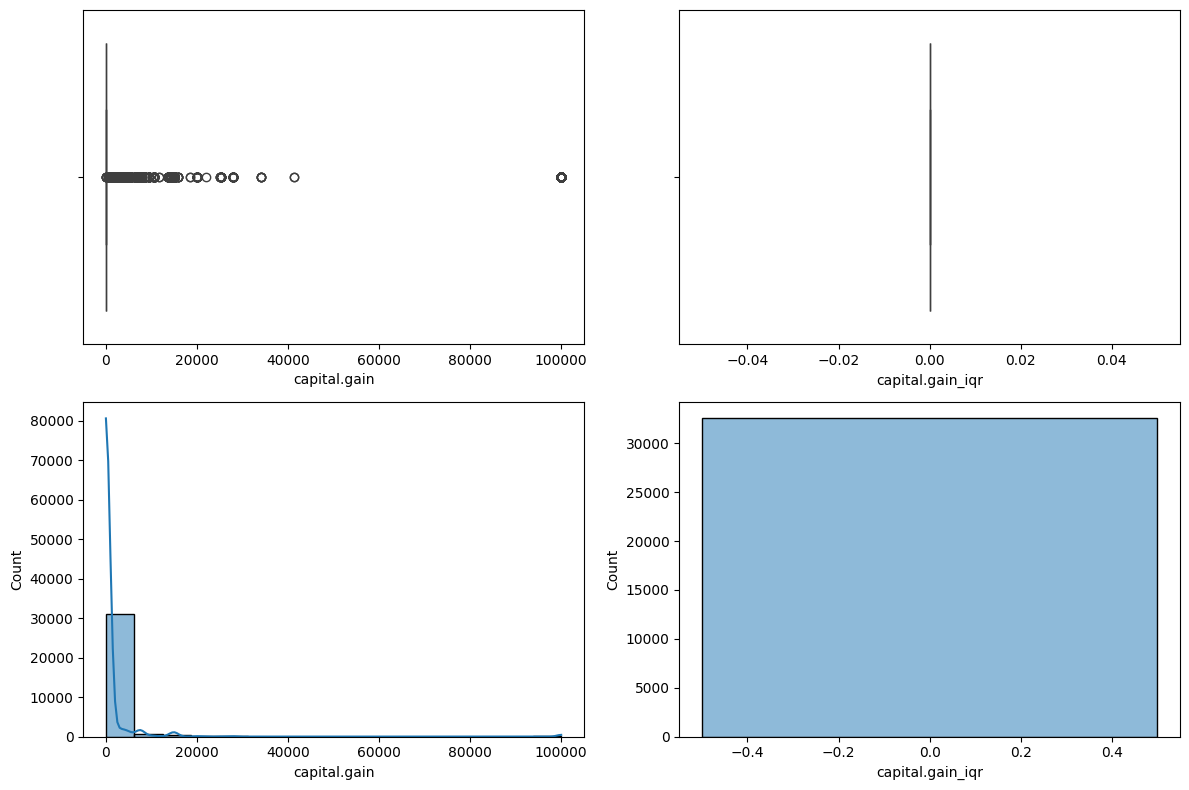

In [227]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.boxplot(data=df, x='capital.gain')

plt.subplot(2,2,2)
sns.boxplot(data=df, x='capital.gain_iqr')

plt.subplot(2,2,3)
sns.histplot(data=df, x='capital.gain', kde=True)

plt.subplot(2,2,4)
sns.histplot(data=df, x='capital.gain_iqr', kde=True)

plt.tight_layout()
plt.show()

In [228]:
Q1 = df['capital.loss'].quantile(0.25)
Q3 = df['capital.loss'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [229]:
df['capital.loss_iqr'] = np.clip(
    df['capital.loss'],
    lower,
    upper
)

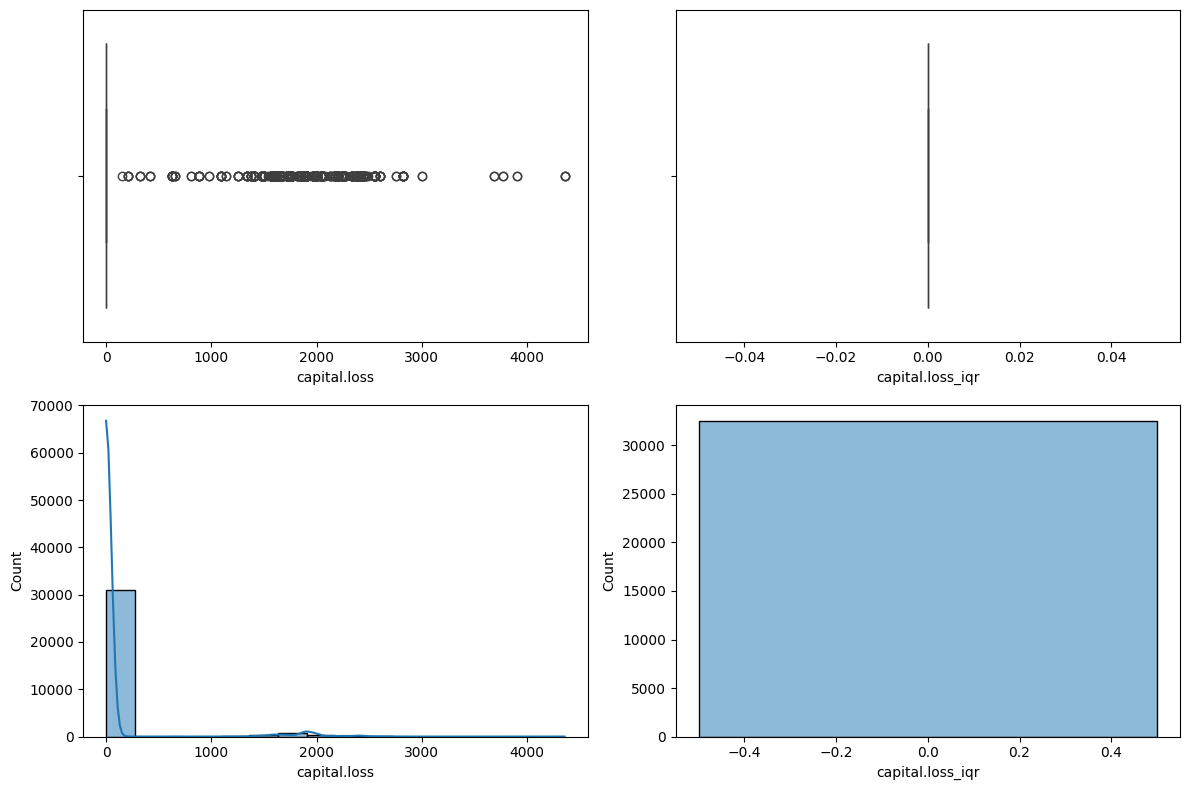

In [230]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.boxplot(data=df, x='capital.loss')

plt.subplot(2,2,2)
sns.boxplot(data=df, x='capital.loss_iqr')

plt.subplot(2,2,3)
sns.histplot(data=df, x='capital.loss', kde=True)

plt.subplot(2,2,4)
sns.histplot(data=df, x='capital.loss_iqr', kde=True)

plt.tight_layout()
plt.show()

# Outlier Treatment Using IQR Capping

## Objective

Reduce the impact of extreme values while preserving observations.

## Method

Interquartile Range (IQR)

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside the bounds are capped.

Encoding

In [231]:
encoded_df = pd.get_dummies(
    df,
    drop_first=True
)

In [232]:
encoded_df.drop(['capital.loss','capital.gain'],axis=1,inplace=True)

In [233]:
encoded_df.head()

,age,education.num,hours.per.week,capital_gain_log,capital_loss_log,capital.gain_iqr,capital.loss_iqr,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,occupation_group_Skilled Labor,occupation_group_White Collar,family_role_Independent Adult,family_role_Relative,family_role_Spouse,investment_activity_Yes,region_Europe,region_Latin America,region_North America,region_Other
0,90,9,40,0.0,8.379539,0,0,False,False,True,...,False,True,True,False,False,True,False,False,True,False
1,82,9,18,0.0,8.379539,0,0,False,False,True,...,False,True,True,False,False,True,False,False,True,False
2,66,10,40,0.0,8.379539,0,0,False,False,True,...,False,True,True,False,False,True,False,False,True,False
3,54,4,40,0.0,8.268988,0,0,False,False,True,...,True,False,True,False,False,True,False,False,True,False
4,41,10,40,0.0,8.268988,0,0,False,False,True,...,False,True,False,False,False,True,False,False,True,False


In [234]:
encoded_df.shape

(32537, 127)

In [235]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Columns: 127 entries, age to region_Other
dtypes: bool(120), float64(2), int64(5)
memory usage: 5.7 MB


# Feature Engineering Summary

## Features Created

1. age_group
2. work_intensity
3. education_level
4. marital_group
5. occupation_group
6. family_role
7. investment_activity
8. capital_gain_log
9. capital_loss_log
10. capital.gain_iqr
11. capital.loss_iqr

## Benefits

- Reduced cardinality
- Reduced skewness
- Handled outliers
- Improved business interpretability
- Improved model readiness

# Engineered Features Evaluation

## Successful Transformations

1. age_group
2. work_intensity
3. education_level
4. marital_group
5. occupation_group
6. family_role
7. region
8. investment_activity

## Distribution Improvements

- Reduced category cardinality
- Reduced feature sparsity
- Improved business interpretability

## Numerical Transformations

- capital_gain_log
- capital_loss_log

Reduced skewness significantly.

## Outlier Treatment

- capital.gain_iqr
- capital.loss_iqr

Reduced influence of extreme observations.

# Conclusion

Feature engineering successfully transformed raw features into more meaningful representations.

Key Improvements:

- Reduced categorical cardinality
- Reduced skewness through log transformation
- Treated extreme outliers using IQR capping
- Created business-oriented features
- Improved dataset interpretability

The dataset is now prepared for feature selection, scaling, and machine learning model development.